
# Dimensionality Reduction using PCA: Application to Fashion MNIST

In this example, we will use Principal Components Analysis as a dimensionality reduction tool. 
**Dimensionality reduction** consists in taking a matrix (rows are subjects/objects/individuals and colomns are observations/features) and "compressing it" to a new matrix, with less new observations. The objective is to reduce the number of observations (the dimension), while preserving as much as possible the information contained/expressed by the originbal data (matrix).


## Dataset

We will use in this example, the fashion MNIST dataset. Let's load it and explore its content

In [16]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import normalize 

df = pd.read_csv("fashion-mnist_test.csv")
X = df.iloc[:, 1:] # The Original matrix. Each row is an 28x28 gray-level image.
y = df.iloc[:, :1] # The class of the image.

Xn = X.values 
yn = y.values 

X_norm = Xn / 255

## Let's explore the content of MNIST Fashion dataset.

Work to do :
- Determine the number of images in the dataset from y.
- Determine the number of classes from y.
- Load a sample of 6 randomly selected images (remember that the size of the iamges is 28x28).
- Plot the six images
- Add a text description of the dataset here :

Fashion-MNIST is a dataset of 28×28 grayscale images representing 10 different types of clothing, such as shirts, shoes, trousers, and bags.

To plot an image, you can use:
- plt.imshow(Xn[45].reshape(28,28), cmap='gray_r', interpolation='nearest')
    
To select a random image index you can use:
- randIndex= np.random.randint(number_images)

The full description of this datset is available following the URL:
https://research.zalando.com/welcome/mission/research-projects/fashion-mnist/


The number of images = 10000
The number of classes = 10


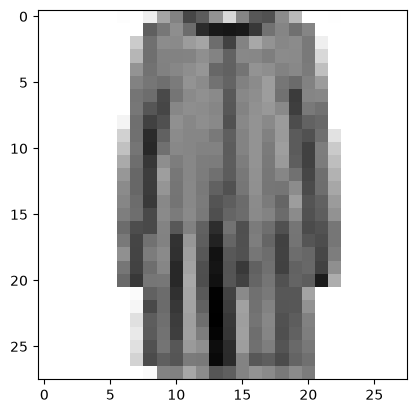

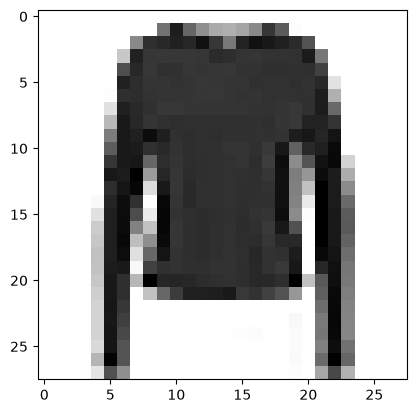

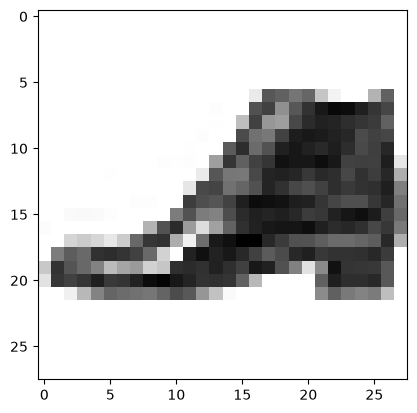

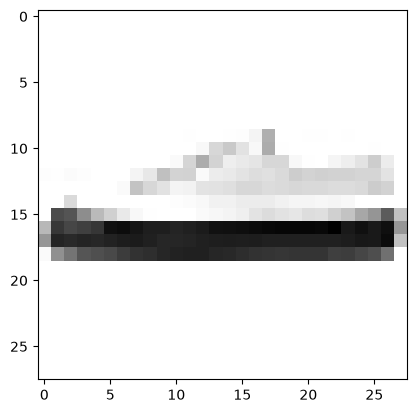

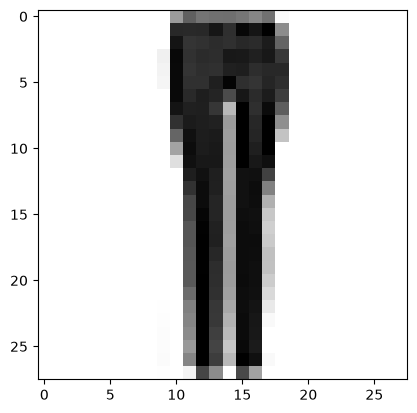

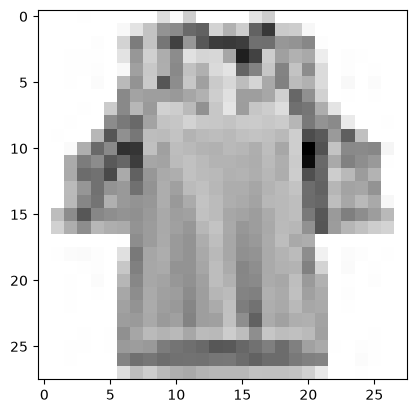

In [17]:
from matplotlib import pyplot as plt

# COMPLETE THE CODE HERE
number_images = y.shape[0]
number_classes = len(np.unique(y))

print('The number of images = {}'.format(number_images))
print('The number of classes = {}'.format(number_classes))

# COMPLETE THE CODE HERE
random_indices = np.random.choice(number_images, 6, replace=False)

for idx in random_indices:
    plt.imshow(Xn[idx].reshape(28,28), cmap='gray_r')
    plt.show()


## Before starting...

Let's have a look to the mean and the standard deviation of our data...

To do:
- Plot the mean image.
- Compute the standard deviation and plot it.
- Analyze the mean and the STD. 

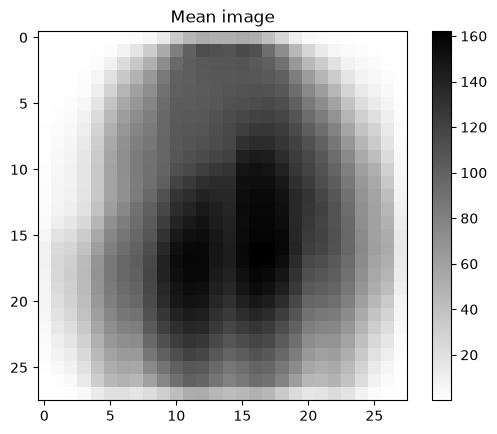

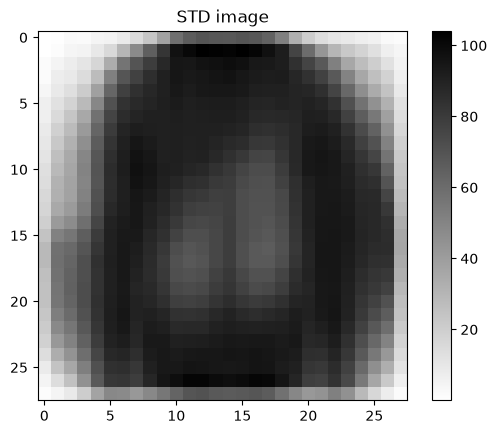

In [18]:
m = np.mean(Xn, axis=0)
plt.imshow(m.reshape(28,28), cmap='gray_r')
plt.title("Mean image")
plt.colorbar()
plt.show()

m = np.std(Xn, axis=0)
plt.imshow(m.reshape(28,28), cmap='gray_r')
plt.title("STD image")  
plt.colorbar()
plt.show()

### Your comments and analysis: 
- The mean image shows the average shape of all images, which looks like a blurry shirt because most items are upper-body clothes centered in the middle. The background pixels are dark because they are always empty.
- The standard deviation image shows where pixel values vary the most. The highest variation is around the outlines, sleeves, and collars, while the borders have zero variation since the background is always black.


## Application of PCA on the data: 1st scenario

Work to do :
- Apply PCA on data stored in X and keep only the 5 first components.
- Transform the data X using the computed PCA and store the result in X_r.
- Plot the 4 first components an images. The components are stored in pca.components_

The result of applying PCA on Fashion MNIST : Each principal component is a potentially interpretable picture of what each vector is finding.


Work to do :
- For each of the 4 first components, print the corresponding "explained variance ratio". 
- Comment the pictures.

Component 1: 29.03%


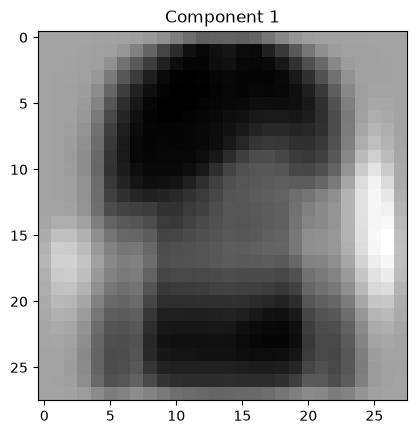

Component 2: 17.90%


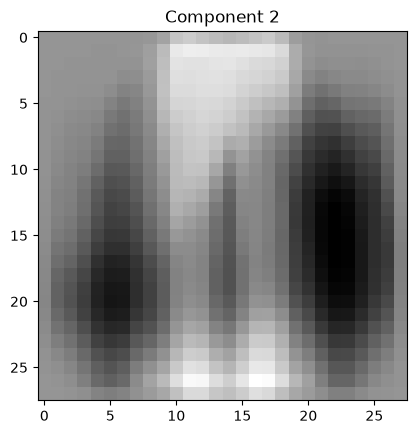

Component 3: 5.96%


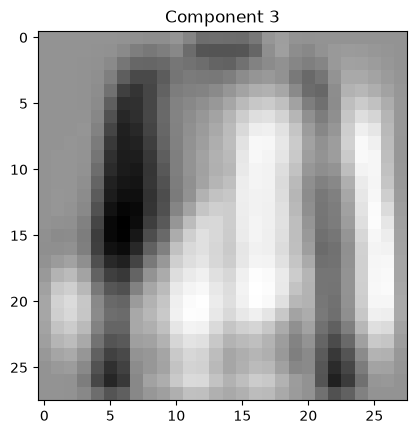

Component 4: 4.98%


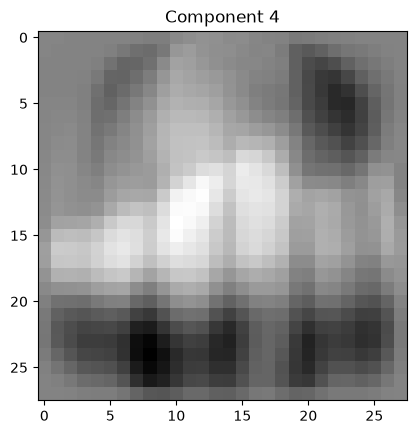

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
Xn_r = pca.fit(Xn).transform(Xn)

# COMPLETE THE CODE HERE
for i in range(4):
    print('Component {}: {:.2f}%'.format(i + 1, pca.explained_variance_ratio_[i] * 100))
    plt.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    plt.title('Component {}'.format(i + 1))
    plt.show()


In [20]:
pca.components_.shape

(15, 784)

## And the following components...

- Plot the 10 following components and the corresponding explained variance ratio.
- What do you notice?

### What do you notice?
The explained variance ratio decreases for each component. The first components capture broad shapes, while the following components capture more specific details like shoe soles, heels, and collars.


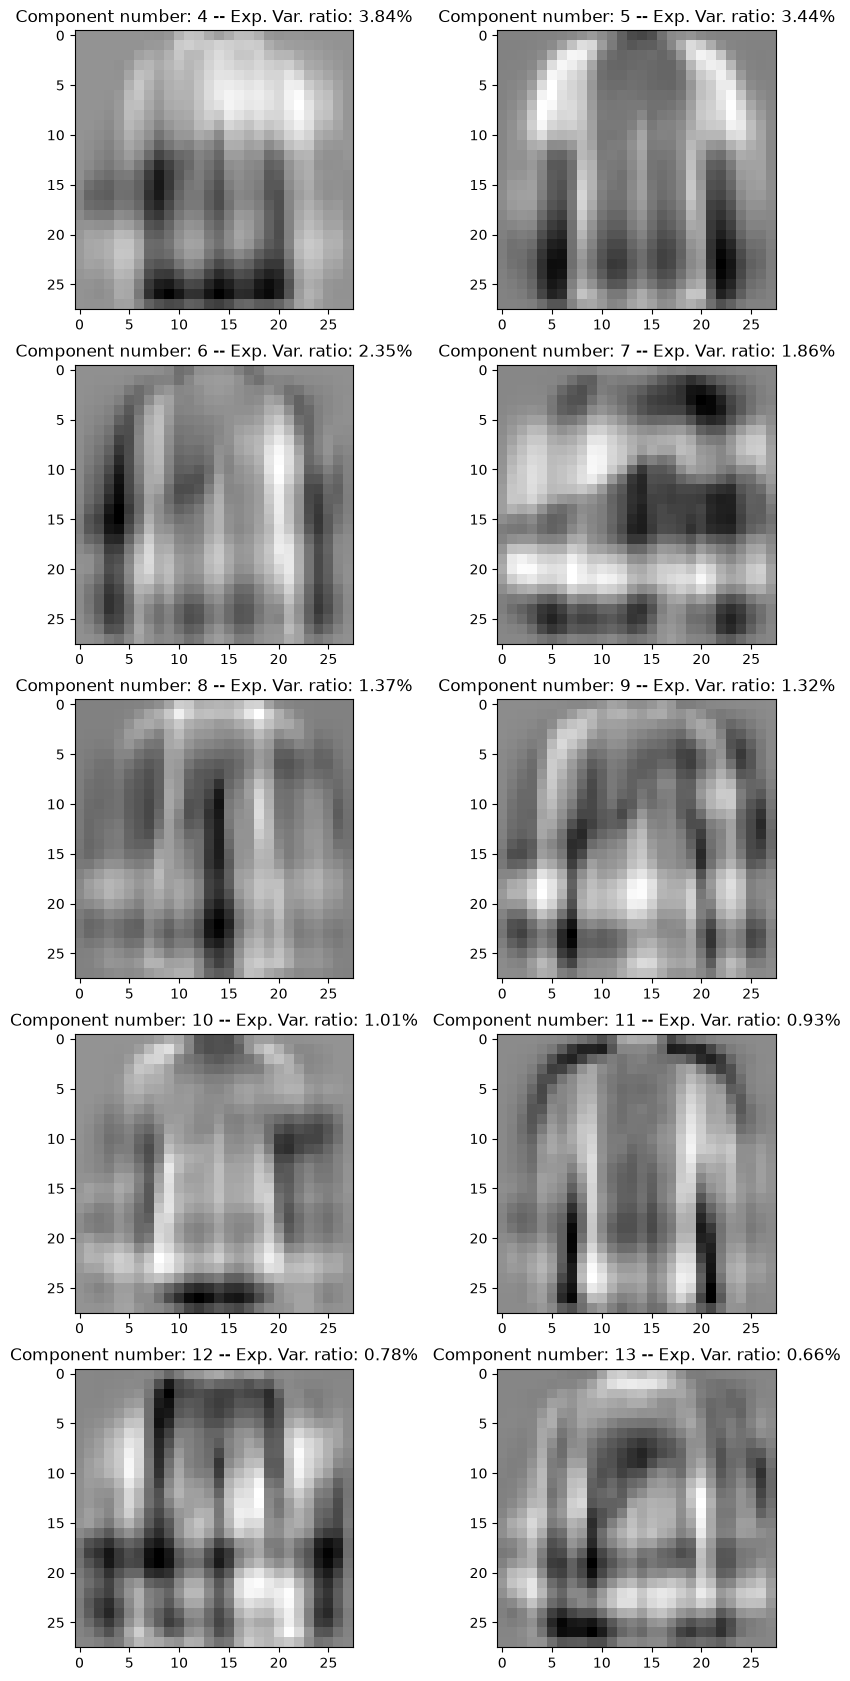

In [21]:
fig = plt.figure()
fig.set_figheight(21)
fig.set_figwidth(10)
for i in range(10):
    ax = pca.components_[i+4, :].reshape(28, 28)
    fig.add_subplot(5,2,i+1)
    plt.imshow(ax, cmap='gray_r')
    plt.title("Component number: {0:} -- Exp. Var. ratio: {1:.2f}%".format(i+4, pca.explained_variance_ratio_[i+4]*100))                                        
    
plt.show()

## How many components should we retain?

You notice that most of these components look like they have some sort of shoe-related thing going on.

Each additional component (dimension) we add to the PCA captures less and less of the variance in the model. 
The first component is the most important one, followed by the second, then the third, and so on.

The question is how to decide how many dimension should kept in the transformed space?

Work to do:
- Plot the explained variance ratio for the 15 first components.
- Plot the cumulative sum of explained variance ratio for the 15 first components.
- Analyse the figures.

Remember:
- The explained variance ratios are stored in "pca.explained_variance_ratio_".
- The objective is to Determine a "cutoff".


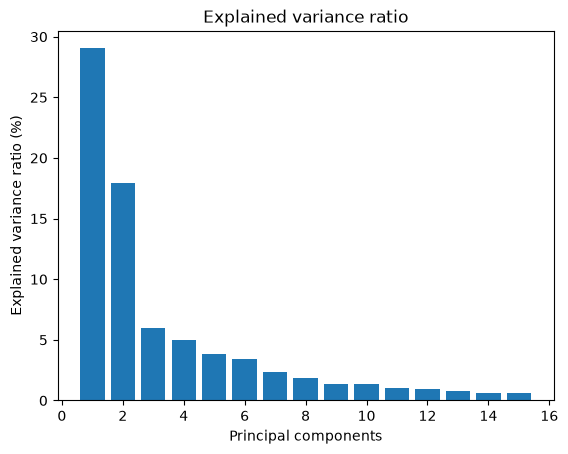

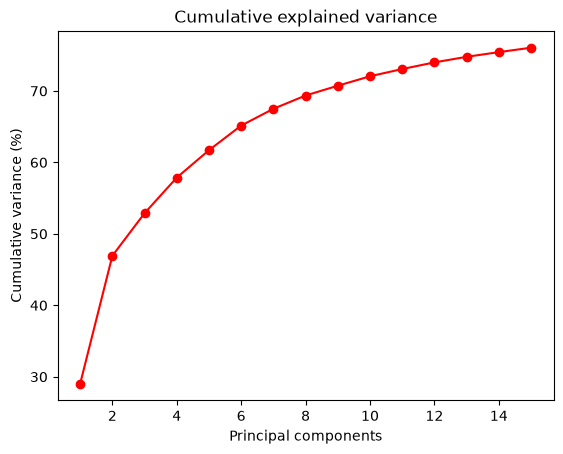

In [22]:
# YOUR CODE HERE...
var_exp = pca.explained_variance_ratio_[:15] * 100
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(1, 16), var_exp)
plt.title('Explained variance ratio')
plt.xlabel('Principal components')
plt.ylabel('Explained variance ratio (%)')
plt.show()

plt.plot(range(1, 16), cum_var_exp, 'r-o')
plt.title('Cumulative explained variance')
plt.xlabel('Principal components')
plt.ylabel('Cumulative variance (%)')
plt.show()


## Figure analysis 
The first two components explain almost 47% of the total variance. After the first few components, the explained variance drops quickly and flattens out. The cumulative explained variance reaches about 76% with 15 components. For dimensionality reduction, keeping around 50 to 80 components would preserve most of the information while reducing the dimension.


## General analysis

The understanding above (specifically, explained variance and understanding how to find and interpret which coefficients go into each dimension-reduced component) is sufficient for using PCA for plug-and-play modeling purposes. However, it's useful to have a "toolbox" for comprehending dimensionality reduction output.

Dimensionality reduction techniques (and more specifically PCA) can be used to understand clusters of variables which co-occur with one another. We can think of each new vector across the dataset values as being some new composite variable that the dimensionality reduction technique has come up with. For example, suppose we find that the third PCA vector is a good indicator of the "shoe-ness" of an item in the Fashion MNIST dataset. We could compute this vector, grab it, and push it back into our original matrix of features as a new column. If we were previously having trouble distinguishing shoes in the dataset, this might significantly increase the accuracy of our model!

Even if none of the variables in the dataset are worth pushing back to our original feature matrix, PCA will still help us probe for new features. If dimensionality reduction picks up shoe-ness in some sense, then that's a good indication that trying to define "shoe-ness" in the data is a good idea to try to engineer as a feature.


## I. Assessing the quality of new reduced space from PCA - Considering reconstruction

One possible way to assess the quality of the reduced space computed using PCA is to analyse the reconstruction process of the original vector from the projected ones.


To do:
- Let's consider again Fashion MNIST. 
- Compute a PCA and keep Rd components => Dimension of the new representation space = Rd
- Project the original vectors to the new Rd-dimensional space (Xn_r).
- Reconstruct the orginal vector from the projected one (XR).
- Plot a randomily selected sample of 6 original images: For each image, plot the reconstructed corresponding image.
- Perform this sequence of steps for different values of Rd: 2, 5, 10, 50, 100, 150
- Analyze and comment the obtained results.


### 1st step: Computing PCA and projecting the original images.

In [23]:
from sklearn.preprocessing import normalize 
Xn_norm = normalize(Xn)

pca = PCA(n_components=150)
Xn_norm_r = pca.fit(Xn_norm).transform(Xn_norm)

### 2nd step: Write a reconstruction function

In [24]:
def reconstruct(X, PCAtrans):
    """
    Creates a reconstruction of an input record, X, given a transformation (PCAtrans)
    
    Note 1: In this dataset each record is the set of pixels in the image (flattened to 
    one row).
    Note 2: R should be normalized before input.
    
    """
    # Invert the PCA transformation.
    ret = PCAtrans.inverse_transform(X)
    
    # This process results in non-normal noise on the margins of the data.
    # We clip the results to fit in the [0, 1] interval.
    ret[ret < 0] = 0
    ret[ret > 255] = 255
    return ret

### 3rd step: Reconstruct and plot

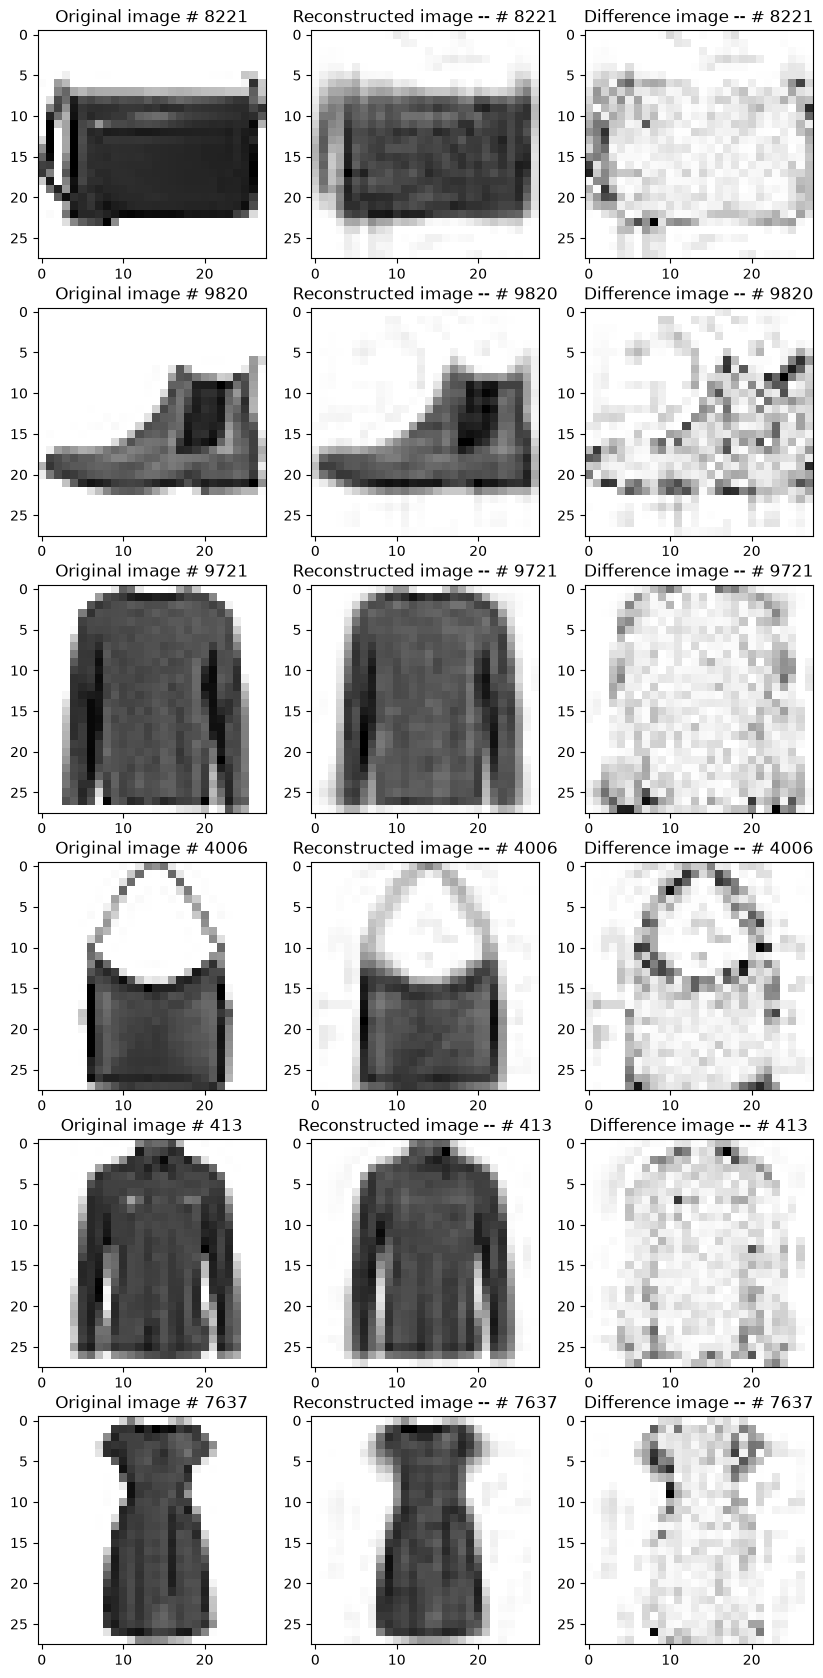

In [25]:
fig = plt.figure()
fig.set_figheight(21)
fig.set_figwidth(10)


for k in range(6):
    cur = np.random.randint(number_images)
    
    a = Xn_norm[cur].reshape(28, 28) # COMPLETE THE CODE HERE ("a" should be the original image # cur)
    fig.add_subplot(6,3,(3*k)+1)
    plt.imshow(a, cmap='gray_r')
    plt.title('Original image # {}'.format(cur))

    b = reconstruct(Xn_norm_r[cur:cur+1], pca).reshape(28, 28) # COMPLETE THE CODE HERE ("b" should be the recustructed image of "a")
    fig.add_subplot(6,3,(3*k)+2)
    plt.imshow(b, cmap='gray_r')
    plt.title('Reconstructed image -- # {}'.format(cur))

    c = np.abs(a - b) # COMPLETE THE CODE HERE ("c" should be the image-difference between "a" and "b")
    fig.add_subplot(6,3,(3*k)+3)
    plt.imshow(c, cmap='gray_r')
    plt.title('Difference image -- # {}'.format(cur))

plt.show()


### 4th Step: Reconstruct and plot with different PCA models varying the reduced dimension (5, 10, 50, 100, 150, 200...)

What do you notice?

As the number of components increases, the reconstructed image becomes clearer and closer to the original. With 5 or 10 components, the reconstruction is very blurry. With 50 or 100 components, details like sleeves and outlines are clearly visible, and the difference image has very small values.


## II. Assessing the PCA components - Considering distance of data to components (OPTIONAL)

We can assess the quality of each principal component by analyzing the distribution of the distances of data vectors w.r.t. the principal component.

Let's do it step by step:
- write a function that computes the Euclidien distances between a principal component and all of the vectors.
- Consider the 8 first principal components, and for each component, plot the histogram of its distances (w.r.t. the vectors of the dataset).

In [26]:
from sklearn.preprocessing import normalize 
Xn_norm = normalize(Xn)

pca = PCA(n_components=150)
Xn_norm_r = pca.fit(Xn_norm).transform(Xn_norm)

In [27]:
from scipy.spatial import distance

def record_distance(X, vector):
    
    return pd.Series([distance.euclidean(X[i, :], vector) for i in range(len(X))])

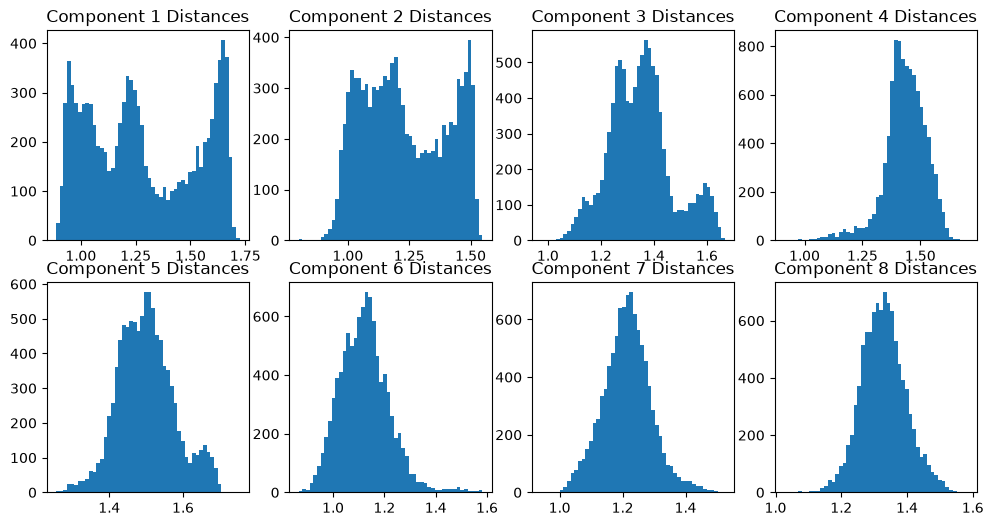

In [28]:
fig, axarr = plt.subplots(2, 4, figsize=(12, 6))
axarr = np.array(axarr).flatten()

for i in range(0, 8):
    record_distance(Xn_norm, pca.components_[i]).plot.hist(bins=50, ax=axarr[i])
    axarr[i].set_title("Component {0} Distances".format(i + 1), fontsize=12)
    axarr[i].set_xlabel("")
    axarr[i].set_ylabel("")

#### Analysis

Each histogram shows the distribution of the Euclidean distances of vectors w.r.t. a principal component.

- Give a description to what would be the histogram shape corresponding to a "bad" principal component.
- Give a description to what would be the histogram shape corresponding to a "good" principal component.

- **Good principal component**: The histogram has a wide spread (high standard deviation). This means different data points have different projections on this component, so it separates the data well.
- **Bad principal component**: The histogram is very narrow and concentrated around a single value (around 1.41) with almost no spread. This means all points have the same distance to it (orthogonal), so the component does not discriminate between samples and only captures noise.


## General Conclusion 

1. PCA reduces the dimensionality of the Fashion-MNIST images from 784 to a much smaller number of features while keeping most of the variance.
2. The first components capture the main shapes and differences between items (like clothes vs shoes), while higher components capture finer details.
3. Image reconstruction shows that keeping around 50 to 100 components is enough to reconstruct images with good quality and low error.
4. Analyzing the distance histograms shows that good components have a wide distribution that separates data points, while bad components have a narrow distribution around 1.41.




NB. This notebook is based on "Selfish Gene's notebooks" and the notebook from Kaggle : https://www.kaggle.com/residentmario/dimensionality-reduction-and-pca-for-fashion-mnist